# 01_preEDA - Khảo sát dữ liệu sơ bộ Digital Burnout

Notebook này thực hiện phân tích dữ liệu sơ bộ trước tiền xử lý cho đề tài:
**"Xây dựng hệ thống dự đoán và phân tích Digital Burnout của sinh viên dựa trên dữ liệu hành vi sử dụng thiết bị và học tập"**

Mục tiêu:
- Khảo sát cấu trúc dữ liệu ban đầu.
- Kiểm tra kiểu dữ liệu, missing values, duplicates.
- Quan sát phân phối ban đầu của một số biến quan trọng.
- Xem nhanh tương quan giữa các triệu chứng burnout cốt lõi.

Notebook này **không thực hiện**:
- Feature Engineering
- Machine Learning
- Phân tích chuyên sâu

## Import thư viện
Nhập các thư viện cần thiết

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Load Dataset
Đọc dữ liệu

In [2]:
file_path = "../data/raw/digital_burnout_productivity_dataset_5M.csv"

df = pd.read_csv(file_path)

print("Dữ liệu đã được tải thành công.")

Dữ liệu đã được tải thành công.


## Dataset Overview
Bao gồm shape (số dòng, số cột), info, head

In [6]:
# Shape

print("Số dòng và số cột của dataset:")
print(df.shape)

# Info
print("\nThông tin về dataset:")
print(df.info())

# Head
print("5 dòng đầu tiên của Dataset")
display(df.head())

Số dòng và số cột của dataset:
(5000000, 34)

Thông tin về dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 34 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   user_id                  int64  
 1   age                      int64  
 2   occupation               object 
 3   work_mode                object 
 4   device_usage_type        object 
 5   daily_screen_time        float64
 6   social_media_hours       float64
 7   doomscrolling_duration   float64
 8   app_switch_frequency     int64  
 9   notification_count       int64  
 10  smartphone_unlocks       int64  
 11  late_night_device_usage  int64  
 12  focus_sessions           int64  
 13  deep_work_hours          float64
 14  distraction_frequency    int64  
 15  task_completion_rate     int64  
 16  concentration_score      int64  
 17  sleep_hours              float64
 18  sleep_quality            int64  
 19  caffeine_intake 

,user_id,age,occupation,work_mode,device_usage_type,daily_screen_time,social_media_hours,doomscrolling_duration,app_switch_frequency,notification_count,smartphone_unlocks,late_night_device_usage,focus_sessions,deep_work_hours,distraction_frequency,task_completion_rate,concentration_score,sleep_hours,sleep_quality,caffeine_intake,physical_activity,stress_level,workspace_quality,meeting_hours,internet_stability,remote_work_days,motivation_level,mental_fatigue,emotional_exhaustion,work_satisfaction,mental_state,burnout_risk,productivity_score,productivity_category
0,1,56,Content Creator,Office,Entertainment-Centric,8.8,5.0,1.2,41,112,49,1,3,6.0,67,92,2,5.9,10,6,1.6,10,5,2.8,3,4,8.0,10,4,8,Balanced,46,100,High
1,2,46,Student,Hybrid,Work-Centric,10.3,2.2,2.4,119,168,153,1,9,4.6,75,74,3,5.6,7,5,1.1,5,10,3.2,7,6,5.0,7,9,7,Balanced,57,96,High
2,3,32,Software Engineer,Remote,Balanced,6.5,4.6,1.0,121,199,234,1,5,NaN,70,96,7,5.5,8,6,1.1,4,1,2.3,9,6,8.0,5,2,6,Balanced,29,79,High
3,4,25,Designer,Office,Balanced,9.6,1.2,0.1,85,122,177,1,9,2.9,107,60,3,6.1,5,1,1.7,1,4,3.8,10,5,6.0,4,5,3,Burnout,57,63,Medium
4,5,38,Analyst,Hybrid,Work-Centric,13.3,1.6,1.9,221,73,91,1,9,2.8,72,73,9,7.9,1,3,1.8,4,8,3.0,1,1,4.0,7,9,7,Focused,64,89,High


## Data Type Analysis
Phần này phân loại các biến thành:
- **Biến định lượng**: thường dùng để mô tả mức độ, tần suất, điểm số hoặc thời lượng.
- **Biến phân loại**: thường dùng để mô tả nhóm, chế độ học/làm việc hoặc loại hành vi sử dụng thiết bị.

In [8]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Số lượng biến định lượng:", len(numerical_columns))
print(numerical_columns)

print("\nSố lượng biến phân loại:", len(categorical_columns))
print(categorical_columns)

Số lượng biến định lượng: 29
['user_id', 'age', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'app_switch_frequency', 'notification_count', 'smartphone_unlocks', 'late_night_device_usage', 'focus_sessions', 'deep_work_hours', 'distraction_frequency', 'task_completion_rate', 'concentration_score', 'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity', 'stress_level', 'workspace_quality', 'meeting_hours', 'internet_stability', 'remote_work_days', 'motivation_level', 'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction', 'burnout_risk', 'productivity_score']

Số lượng biến phân loại: 5
['occupation', 'work_mode', 'device_usage_type', 'mental_state', 'productivity_category']


In [9]:
# Hiển thị bảng kiểu dữ liệu

data_types = pd.DataFrame({
    "column_name": df.columns,
    "data_type": df.dtypes.astype(str),
    "non_null_count": df.notnull().sum().values,
    "null_count": df.isnull().sum().values,
    "unique_values": df.nunique().values
})

data_types

,column_name,data_type,non_null_count,null_count,unique_values
user_id,user_id,int64,5000000,0,5000000
age,age,int64,5000000,0,42
occupation,occupation,object,5000000,0,7
work_mode,work_mode,object,5000000,0,3
device_usage_type,device_usage_type,object,5000000,0,3
daily_screen_time,daily_screen_time,float64,5000000,0,171
social_media_hours,social_media_hours,float64,4900000,100000,121
doomscrolling_duration,doomscrolling_duration,float64,5000000,0,80
app_switch_frequency,app_switch_frequency,int64,5000000,0,240
notification_count,notification_count,int64,5000000,0,380


## Missing Values Analysis

Phần này kiểm tra số lượng và tỷ lệ giá trị thiếu ở từng biến.

Nếu biến có tỷ lệ thiếu cao, bước tiền xử lý sau này cần cân nhắc:
- Loại bỏ biến.
- Điền giá trị phù hợp.
- Kiểm tra nguyên nhân thiếu dữ liệu.


In [10]:
missing_values = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().mean() * 100
})

missing_values = missing_values.sort_values(by="missing_percent", ascending=False)

missing_values

,missing_count,missing_percent
sleep_hours,100000,2.0
social_media_hours,100000,2.0
deep_work_hours,100000,2.0
motivation_level,100000,2.0
mental_state,0,0.0
work_satisfaction,0,0.0
burnout_risk,0,0.0
emotional_exhaustion,0,0.0
mental_fatigue,0,0.0
sleep_quality,0,0.0


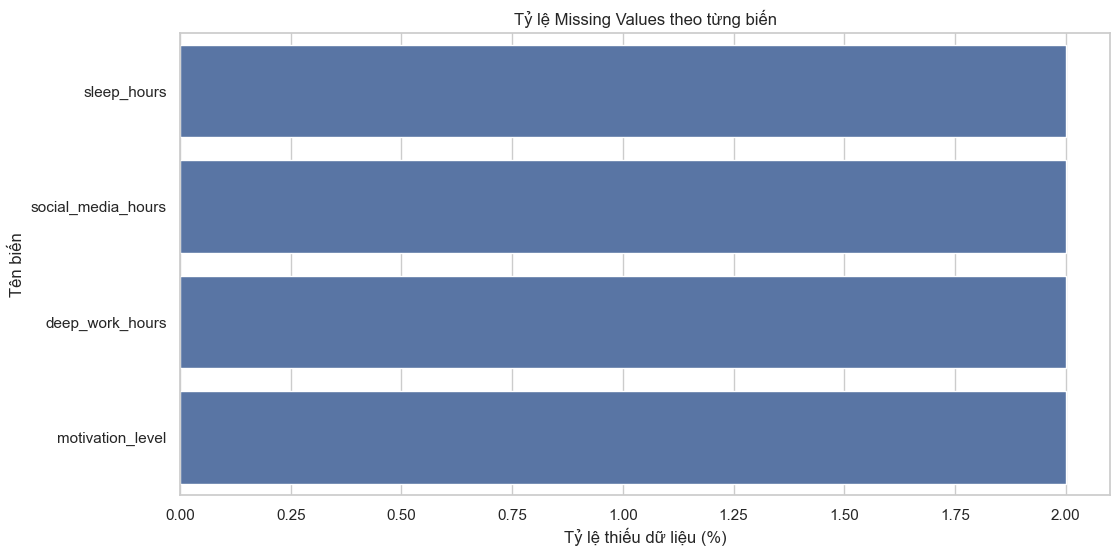

In [11]:
# Biểu đồ Missing Values

missing_plot = missing_values[missing_values["missing_count"] > 0]

if missing_plot.empty:
    print("Không phát hiện missing values trong dataset.")
else:
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=missing_plot.reset_index(),
        x="missing_percent",
        y="index"
    )
    plt.title("Tỷ lệ Missing Values theo từng biến")
    plt.xlabel("Tỷ lệ thiếu dữ liệu (%)")
    plt.ylabel("Tên biến")
    plt.show()

## Duplicate Analysis

Phần này kiểm tra các dòng dữ liệu bị trùng lặp hoàn toàn.

Nếu tồn tại duplicates, bước tiền xử lý sau này cần xem xét loại bỏ để tránh làm sai lệch phân tích và mô hình dự đoán.

In [12]:
duplicate_count = df.duplicated().sum()
duplicate_percent = duplicate_count / len(df) * 100

print("Số dòng trùng lặp:", duplicate_count)
print(f"Tỷ lệ dòng trùng lặp: {duplicate_percent:.4f}%")

Số dòng trùng lặp: 0
Tỷ lệ dòng trùng lặp: 0.0000%


In [13]:
# Xem thử một số dòng bị trùng nếu có
if duplicate_count > 0:
    df[df.duplicated()].head()
else:
    print("Không phát hiện dòng trùng lặp.")

Không phát hiện dòng trùng lặp.


## Descriptive Statistics

Phần thống kê mô tả giúp quan sát nhanh:
- Giá trị trung bình.
- Trung vị.
- Độ lệch chuẩn.
- Giá trị nhỏ nhất và lớn nhất.

Các thống kê này giúp phát hiện sơ bộ biến có phân phối bất thường hoặc phạm vi giá trị cần kiểm tra ở bước tiền xử lý.

In [18]:
df.describe().T

# Thống kê mô tả các biến phân loại

print("Thống kê mô tả các biến phân loại")

if categorical_columns:
    display(df[categorical_columns].describe().T)
else:
    print("Không có biến phân loại.")
    
# Thống kê cơ bản mở rộng cho các biến số
print("Thống kê cơ bản mở rộng cho các biến số")

basic_stats = df[numerical_columns].agg(["mean", "median", "std", "min", "max"]).T
basic_stats

Thống kê mô tả các biến phân loại


,count,unique,top,freq
occupation,5000000,7,Freelancer,715500
work_mode,5000000,3,Remote,2250774
device_usage_type,5000000,3,Balanced,1749883
mental_state,5000000,4,Distracted,1500163
productivity_category,5000000,3,High,2374159


Thống kê cơ bản mở rộng cho các biến số


,mean,median,std,min,max
user_id,2.500000e+06,2500000.5,1.443376e+06,1.0,5000000.0
age,3.849935e+01,38.0,1.212046e+01,18.0,59.0
daily_screen_time,8.001010e+00,8.0,2.494805e+00,1.0,18.0
social_media_hours,3.517651e+00,3.5,1.759434e+00,0.0,12.0
doomscrolling_duration,1.834645e+00,1.8,1.132208e+00,0.0,7.9
app_switch_frequency,1.294981e+02,129.0,6.928145e+01,10.0,249.0
notification_count,2.094380e+02,209.0,1.096646e+02,20.0,399.0
smartphone_unlocks,1.570431e+02,157.0,8.228162e+01,15.0,299.0
late_night_device_usage,6.499932e-01,1.0,4.769718e-01,0.0,1.0
focus_sessions,4.500512e+00,5.0,2.872723e+00,0.0,9.0


## Initial Distribution Analysis

Phần này quan sát phân phối ban đầu của một số biến quan trọng:

- `burnout_risk`: mức rủi ro burnout.
- `productivity_score`: điểm năng suất.
- `daily_screen_time`: thời gian sử dụng màn hình mỗi ngày.
- `social_media_hours`: thời gian sử dụng mạng xã hội.
- `sleep_hours`: thời lượng ngủ.

Ở giai đoạn này, biểu đồ chỉ dùng để nhận diện xu hướng sơ bộ, chưa kết luận chuyên sâu.

In [ ]:
selected_distribution_columns = [
    "burnout_risk",
    "productivity_score",
    "daily_screen_time",
    "social_media_hours",
    "sleep_hours"
]

available_distribution_columns = [
    col for col in selected_distribution_columns if col in df.columns
]

available_distribution_columns

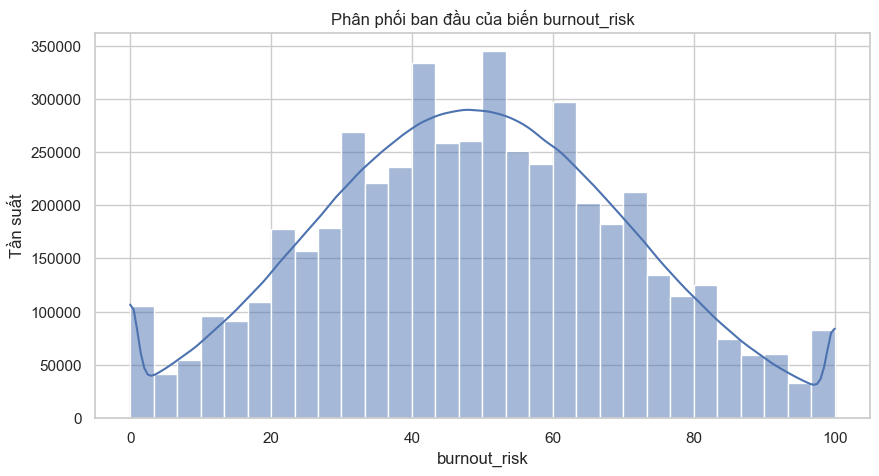

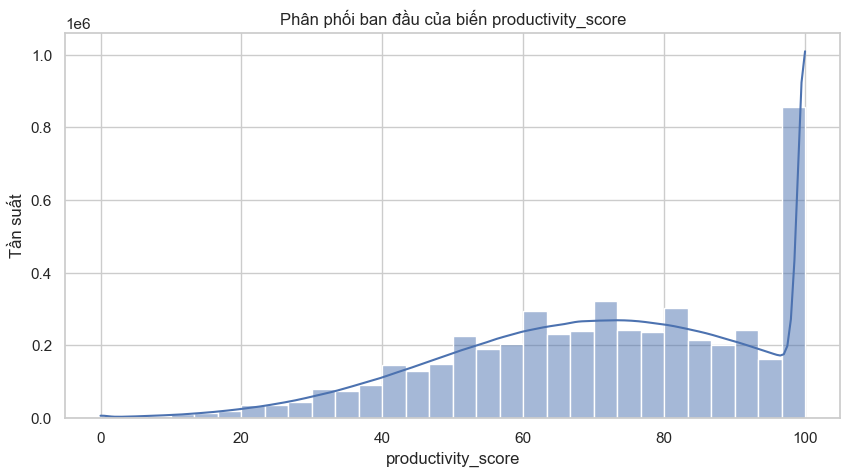

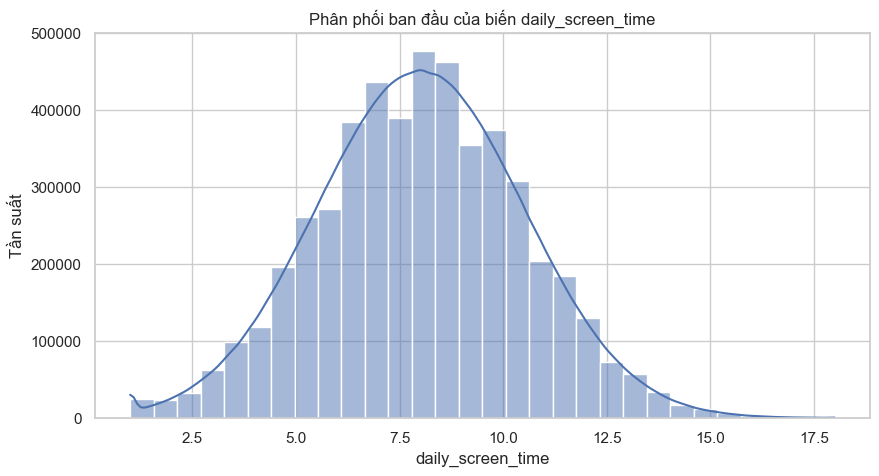

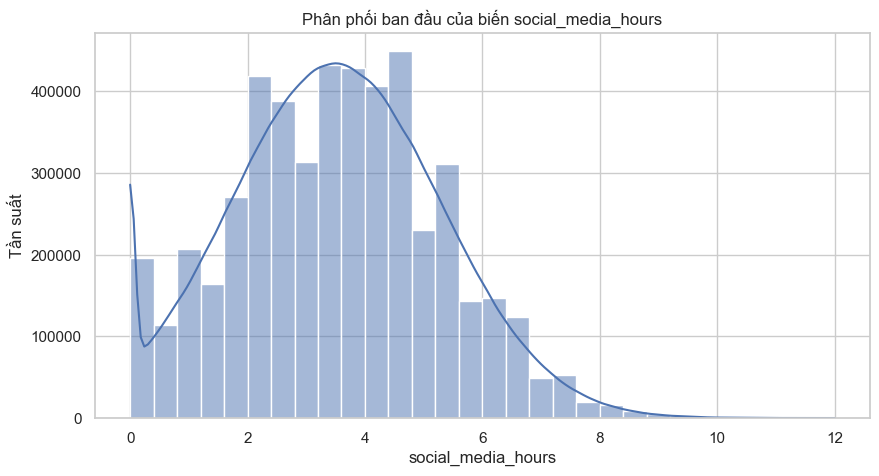

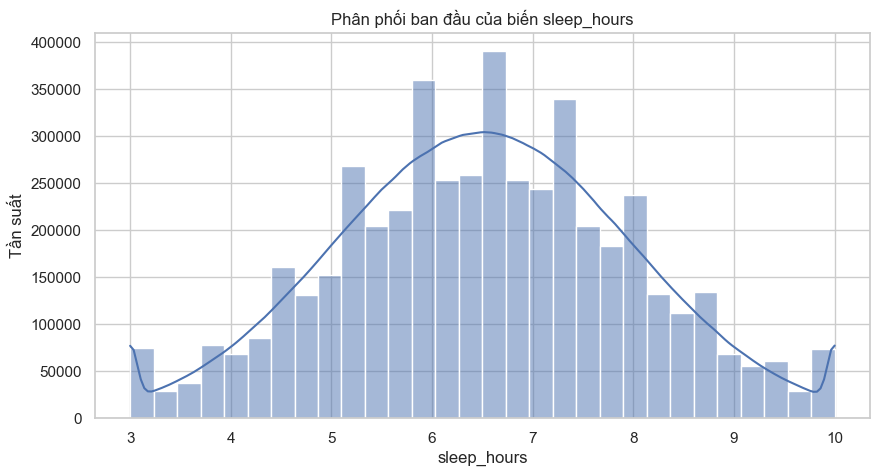

In [20]:
# Vẽ histogram cho các biến quan trọng ban đầu

for col in available_distribution_columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Phân phối ban đầu của biến {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.show()
    

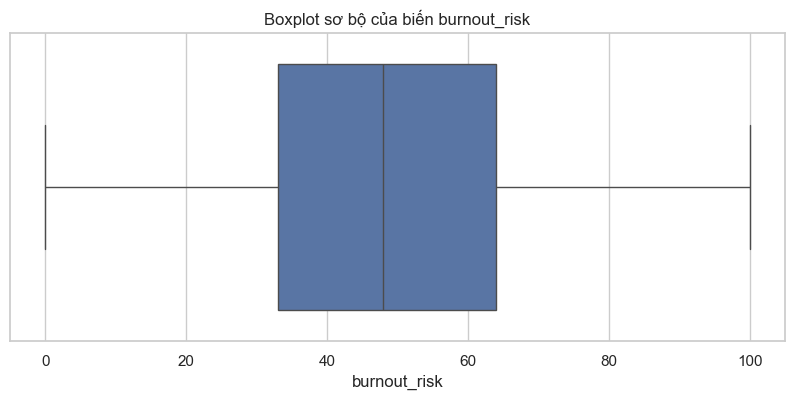

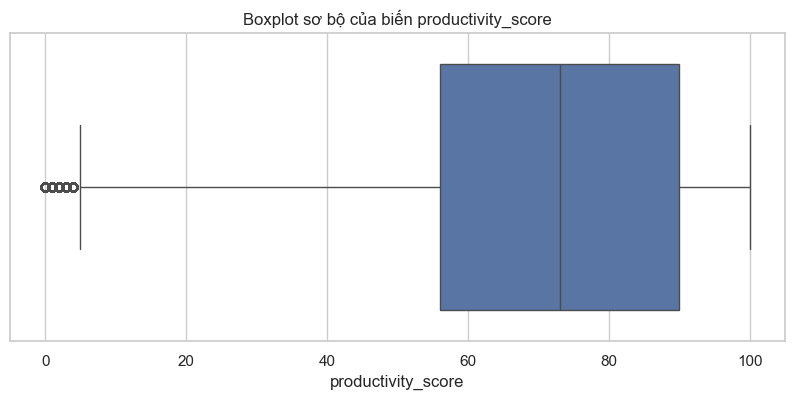

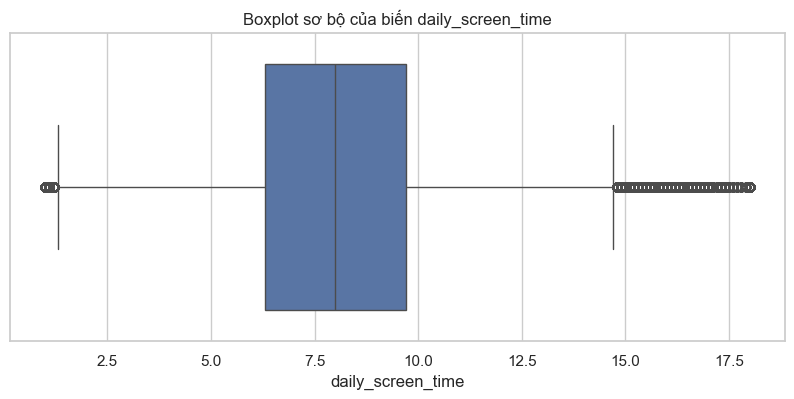

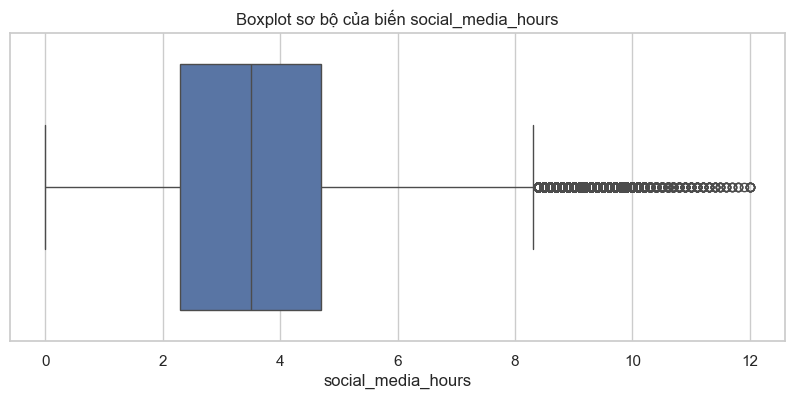

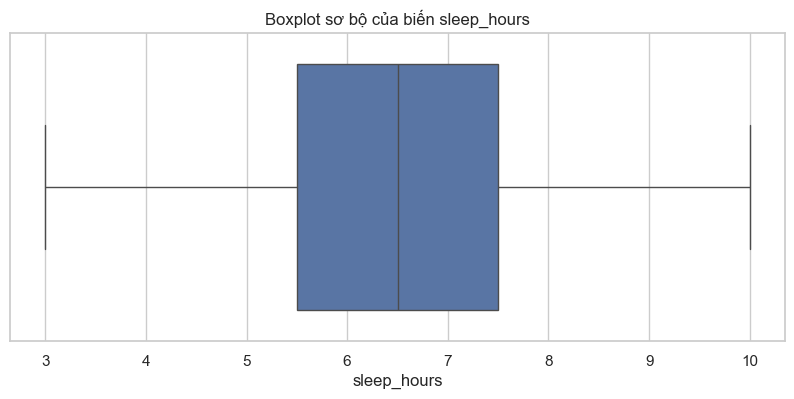

In [21]:
# Boxplot để quan sát sơ bộ giá trị ngoại lệ

for col in available_distribution_columns:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot sơ bộ của biến {col}")
    plt.xlabel(col)
    plt.show()

## Initial Correlation Snapshot

Phần này xem nhanh tương quan giữa:
- `burnout_risk`
- `emotional_exhaustion`
- `stress_level`
- `mental_fatigue`

Mục tiêu là kiểm tra sơ bộ liệu các triệu chứng burnout cốt lõi có xu hướng liên hệ với mức rủi ro burnout hay không.

Đây chỉ là ảnh chụp tương quan ban đầu, chưa thay thế cho phân tích thống kê chuyên sâu.

In [22]:
correlation_columns = [
    "burnout_risk",
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue"
]

available_correlation_columns = [
    col for col in correlation_columns if col in df.columns
]

correlation_matrix = df[available_correlation_columns].corr()

correlation_matrix

,burnout_risk,emotional_exhaustion,stress_level,mental_fatigue
burnout_risk,1.000000,0.511981,0.382824,-0.000124
emotional_exhaustion,0.511981,1.000000,0.000478,0.000216
stress_level,0.382824,0.000478,1.000000,-0.000555
mental_fatigue,-0.000124,0.000216,-0.000555,1.000000


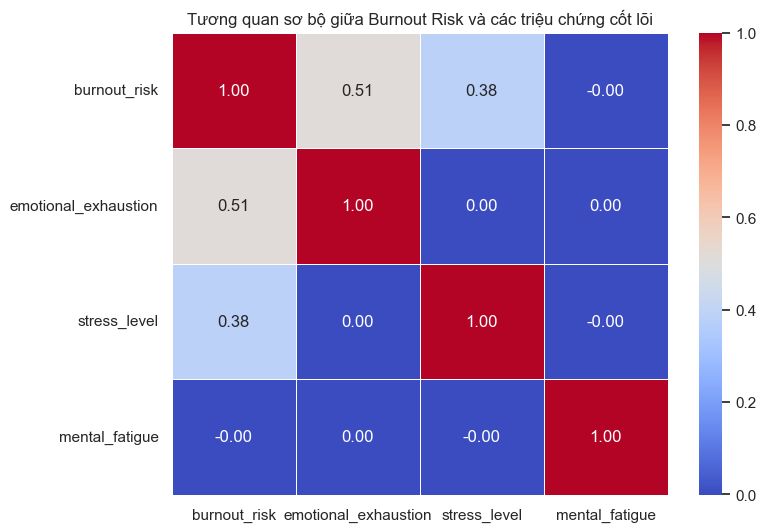

In [23]:
# Heatmap tương quan ban đầu

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Tương quan sơ bộ giữa Burnout Risk và các triệu chứng cốt lõi")
plt.show()

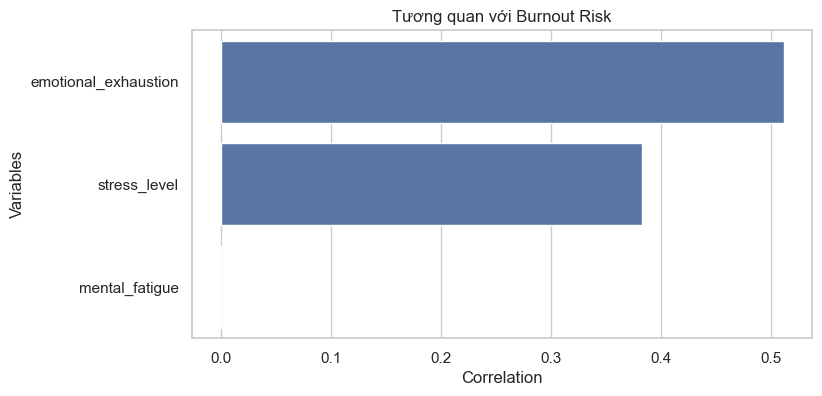

In [25]:
# Tương quan với burnout_risk

if "burnout_risk" in available_correlation_columns:

    burnout_corr = (
        correlation_matrix["burnout_risk"]
        .drop("burnout_risk")
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(8,4))

    sns.barplot(
        x=burnout_corr.values,
        y=burnout_corr.index
    )

    plt.title("Tương quan với Burnout Risk")
    plt.xlabel("Correlation")
    plt.ylabel("Variables")
    plt.show()

else:
    print("Không tìm thấy biến burnout_risk trong dataset.")

## Key Findings Summary

Từ khảo sát sơ bộ, notebook ghi nhận các thông tin chính:

1. Dataset có quy mô lớn, phù hợp để phân tích hành vi sử dụng thiết bị và trạng thái học tập của sinh viên.
2. Các biến được chia thành nhóm định lượng và phân loại để thuận tiện cho bước tiền xử lý.
3. Missing values và duplicates đã được kiểm tra nhưng chưa xử lý trong notebook này.
4. Một số biến quan trọng như `burnout_risk`, `productivity_score`, `daily_screen_time`, `social_media_hours`, `sleep_hours` đã được quan sát phân phối ban đầu.
5. Tương quan sơ bộ giữa `burnout_risk` và các triệu chứng burnout cốt lõi được dùng làm cơ sở cho các bước EDA chuyên sâu sau này.

Notebook này đóng vai trò là bước **Pre-EDA**, giúp hiểu dữ liệu trước khi thực hiện cleaning, preprocessing và modeling.

In [26]:
print("TÓM TẮT KHẢO SÁT SƠ BỘ")
print("-" * 50)

print(f"1. Dataset có {df.shape[0]:,} dòng và {df.shape[1]} cột.")

print(f"2. Số biến định lượng: {len(numerical_columns)}")
print(f"3. Số biến phân loại: {len(categorical_columns)}")

total_missing = df.isnull().sum().sum()
print(f"4. Tổng số giá trị thiếu: {total_missing:,}")

print(f"5. Số dòng trùng lặp: {duplicate_count:,}")

if "burnout_risk" in df.columns:
    print(f"6. Giá trị trung bình của burnout_risk: {df['burnout_risk'].mean():.3f}")

if "productivity_score" in df.columns:
    print(f"7. Giá trị trung bình của productivity_score: {df['productivity_score'].mean():.3f}")

if "daily_screen_time" in df.columns:
    print(f"8. Thời gian sử dụng màn hình trung bình: {df['daily_screen_time'].mean():.3f}")

if "sleep_hours" in df.columns:
    print(f"9. Thời lượng ngủ trung bình: {df['sleep_hours'].mean():.3f}")

print("-" * 50)
print("Notebook này chỉ dừng ở mức khảo sát sơ bộ trước tiền xử lý.")

TÓM TẮT KHẢO SÁT SƠ BỘ
--------------------------------------------------
1. Dataset có 5,000,000 dòng và 34 cột.
2. Số biến định lượng: 29
3. Số biến phân loại: 5
4. Tổng số giá trị thiếu: 400,000
5. Số dòng trùng lặp: 0
6. Giá trị trung bình của burnout_risk: 48.584
7. Giá trị trung bình của productivity_score: 71.444
8. Thời gian sử dụng màn hình trung bình: 8.001
9. Thời lượng ngủ trung bình: 6.501
--------------------------------------------------
Notebook này chỉ dừng ở mức khảo sát sơ bộ trước tiền xử lý.
